# Autoencoder for Image Denoising - MNIST

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.datasets import mnist

### 1. Load and preprocess the MNIST dataset

In [2]:
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print(x_train.shape, x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28, 1) (10000, 28, 28, 1)


### 2. Add artificial noise to create noisy input images

In [3]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(0, 1, x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(0, 1, x_test.shape)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

### 3. Build the Denoising Autoencoder

In [4]:
input_img = layers.Input(shape=(28, 28, 1))

# Encoder
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoded)
x = layers.UpSampling2D((2, 2))(x)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = layers.UpSampling2D((2, 2))(x)
decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,353 (110.75 KB)

 Trainable params: 28,353 (110.75 KB)

 Non-trainable params: 0 (0.00 B)

### Training

In [5]:
history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 142s 297ms/step - loss: 0.1666 - val_loss: 0.1166
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 136s 290ms/step - loss: 0.1135 - val_loss: 0.1091
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 293ms/step - loss: 0.1084 - val_loss: 0.1055
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 125s 266ms/step - loss: 0.1055 - val_loss: 0.1032
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 127s 271ms/step - loss: 0.1037 - val_loss: 0.1021
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 126s 269ms/step - loss: 0.1023 - val_loss: 0.1007
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 124s 264ms/step - loss: 0.1013 - val_loss: 0.0997
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 128s 272ms/step - loss: 0.1004 - val_loss: 0.0989
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 125s 266ms/step - loss: 0.0995 - val_loss: 0.0982
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 141s 265ms/step - loss: 0.0988 - val_loss: 0.0976
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 148s 278ms/step - loss: 0.0982 - val_loss: 0.0974
Epoch 12

### 4. Generate denoised outputs on the test set

In [6]:
denoised_images = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step


### 5. Result Visualization - original, noisy, reconstructed

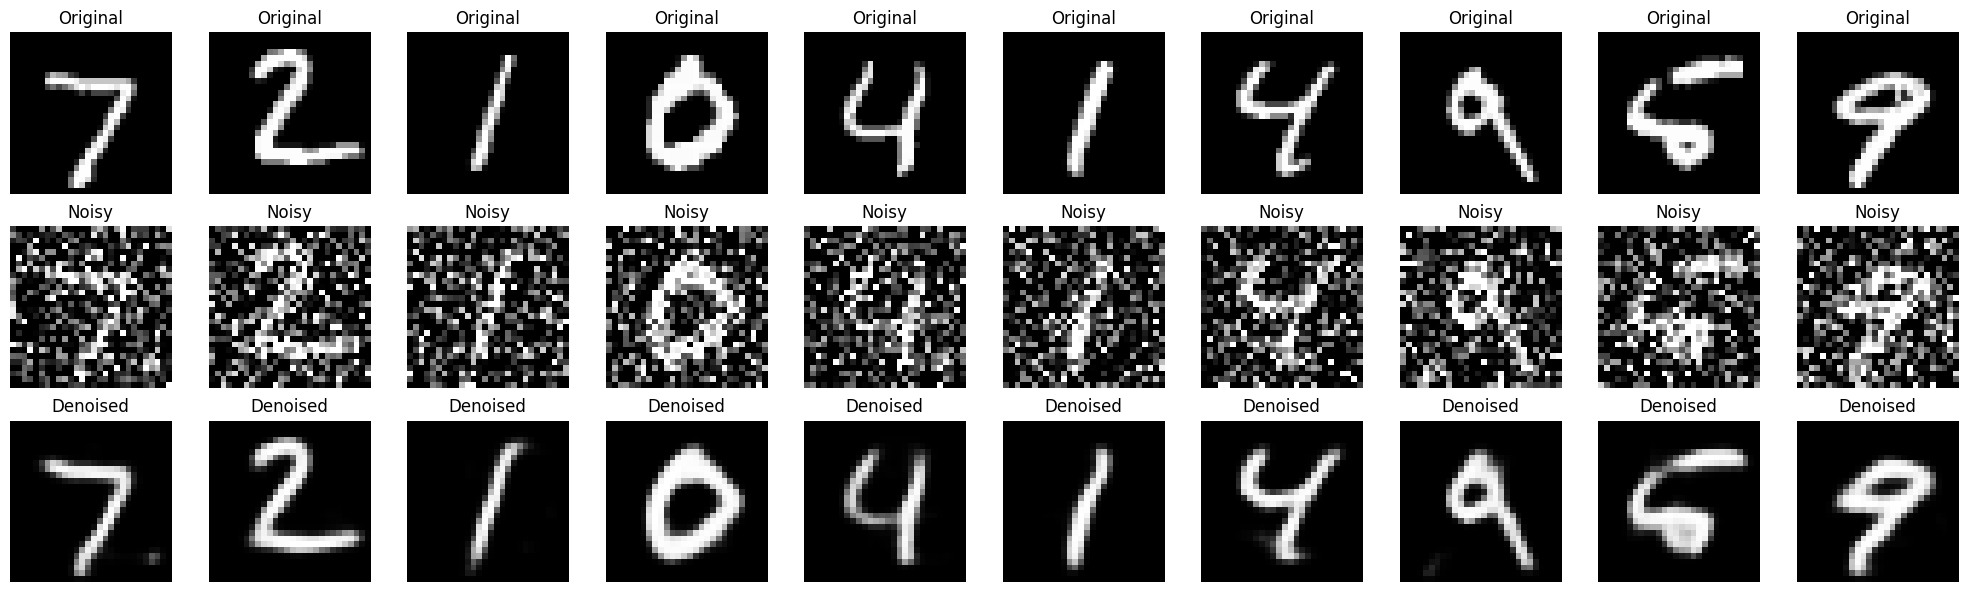

In [7]:
n = 10
plt.figure(figsize=(20, 6))
for i in range(n):
    # original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # noisy
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

    # denoised
    ax = plt.subplot(3, n, i + 1 + 2 * n)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap='gray')
    plt.title("Denoised")
    plt.axis('off')

plt.tight_layout()
plt.show()

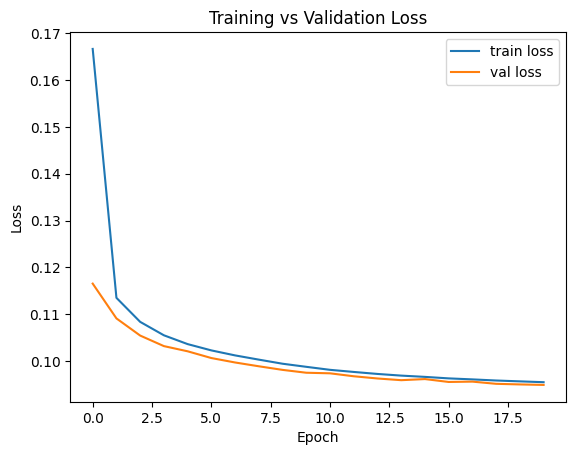

In [8]:
plt.figure()
plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training vs Validation Loss')
plt.show()

### Observations
- The autoencoder learns to remove Gaussian noise while keeping digit shapes intact.
- Convolutional layers preserve spatial structure better than a plain dense autoencoder.
- Higher noise_factor values make reconstruction harder and can blur digit edges.
- Training and validation loss both decrease steadily, showing no major overfitting.